Midterm - Kalkidan Tadese

Question 1

In [1]:
import pandas as pd
# import pandas

In [2]:
# load breast cancer dataset
cancer_data = pd.read_csv('/home/jovyan/work/midtermaters/data.csv')
#subset cancer_data df for select columns
cancersubs = cancer_data[["id","diagnosis", "radius_mean", "texture_mean", "smoothness_mean", "compactness_mean"]]
cdf = cancer_data.copy() #cdf - new copy of og dataframe
# print the data types of each column in df
cdf.dtypes

id                           int64
diagnosis                   object
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float64
concavity_worst     

In [3]:
#using the subset df, we subset cdf to select only 4 features
cdfsub = cancersubs[["radius_mean", "texture_mean", "smoothness_mean", "compactness_mean"]]
stddev = cdfsub.std() #calculate standard deviation of 4 features
print(stddev) #printing out values

radius_mean         3.524049
texture_mean        4.301036
smoothness_mean     0.014064
compactness_mean    0.052813
dtype: float64


2. After calculating the standard deviation for each of the four features using the subset data frame, I printed out the values and noticed that these values were not similar. These values vary significantly -- radius_mean with the largest variation and smoothness_mean with the smallest variation. This is expected as different features have different scales and units of measurements.

In [4]:
# Define function to apply z-score normalization
def mean_time_series(x):
     return (x-x.mean())/x.std()

#save list of the column names for 4 features we want to normalize
x = ["radius_mean", "texture_mean", "smoothness_mean", "compactness_mean"]
for _ in x: # loop through each feature to create a column name
    new_name = _ + "_normalized" 
    cdf[new_name] = cdfsub[_].transform(mean_time_series) #apply normalization function to original column and store as new col
    std = cdf[new_name].std() #calculate std dev for the four normalized columns
    print(f"{new_name}:{std}") #print column + std dev values; formatted with f-strings
    

cdf.head() #display first few lines of df with normalized feature columns

radius_mean_normalized:0.9999999999999999
texture_mean_normalized:1.0000000000000002
smoothness_mean_normalized:0.9999999999999998
compactness_mean_normalized:1.0000000000000004


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32,radius_mean_normalized,texture_mean_normalized,smoothness_mean_normalized,compactness_mean_normalized
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,0.6656,0.7119,0.2654,0.4601,0.11890,NaN,1.096100,-2.071512,1.567087,3.280628
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,0.1866,0.2416,0.1860,0.2750,0.08902,NaN,1.828212,-0.353322,-0.826235,-0.486643
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,0.4245,0.4504,0.2430,0.3613,0.08758,NaN,1.578499,0.455786,0.941382,1.052000
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,0.8663,0.6869,0.2575,0.6638,0.17300,NaN,-0.768233,0.253509,3.280667,3.399917
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,0.2050,0.4000,0.1625,0.2364,0.07678,NaN,1.748758,-1.150804,0.280125,0.538866


3. The standard deviation for the four normalized columns are very similiar with values around 1 or exactly 1.

Question 2

In [5]:
import seaborn as sns #import seaborn for data visualization
import matplotlib.pyplot as plt # import matplot for data visuals
import numpy as np # import numpy for numeric manipulations

/opt/conda/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.11/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/opt/conda/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.11/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future ve

<Figure size 10000x10000 with 0 Axes>

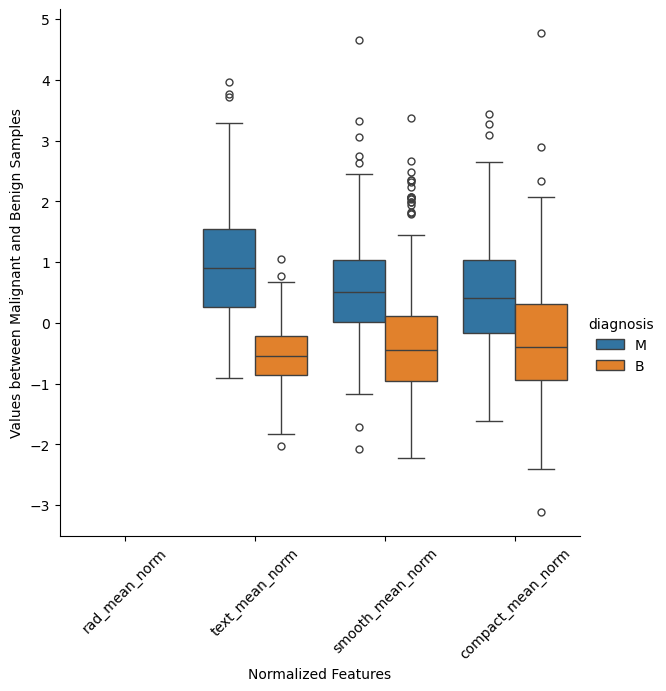

In [6]:
# Create a boxplot for each of the normalized features to visualize the distribution of the values between malignant and benign samples. 
#     Which of the four features do you think will be most accurate in predicting diagnosis by itself? Explain why.
#reshape df from wide to long format for data visualization; id_vars = columns to keep; value_vars = columns to melt (last 4 normalized columns)
cdf_melt = pd.melt(cdf, id_vars = ["diagnosis"], value_vars = cdf.iloc[:,-5:-1], var_name = "Normalized Features", value_name = "Values between Malignant and Benign Samples")
#var_name = new col name for feature types; value_name = new col name for normalized values
cdf_melt #display melted df

#plotting boxplot
plt.figure(figsize=(100,100))
plot = sns.catplot(data = cdf_melt, x="Normalized Features", y="Values between Malignant and Benign Samples", kind="box", hue="diagnosis", height = 6, aspect = 1)
# x set to features; y = normalized values; set kind of plot as box to produce boxplot
# hue to color boxplots according to diagnosis
plot.set_xticklabels(labels = ["rad_mean_norm", "text_mean_norm", "smooth_mean_norm", "compact_mean_norm"], rotation=45)
#set custom x-axis labels and rotate by 45 degress to increase readability
plt.show() #display plot

Of the four features, the radius mean will be most accurate in predicting diagnosis by itself. The interquartile ranges for malignant and benign samples show the least overlap for radius compared to the other features, suggesting that radius values can reliably be used to predict diagnosis. Less overlap suggests fewer misclassifications, ie fewer false positives and negatives.

Question 3

In [7]:
X = cdf[["radius_mean_normalized", "texture_mean_normalized", "smoothness_mean_normalized", "compactness_mean_normalized"]]
#select normalized features from df to store as X 
cdf['Malignant'] = (cdf['diagnosis'] == 'M').astype(int) # astype convert diagnosis column to binary metric
#malignant = 1, benign = 0
y = cdf['Malignant'] #save binary converted data as y 

In [8]:
#import revelant libraries
import math
import statistics
from sklearn.linear_model import LogisticRegression #lib to perform LR
from sklearn.model_selection import train_test_split #lib to split data points
from sklearn.metrics import roc_auc_score

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)
#random_state = 42 # meant to make your random split reproducible? is this not a contradiction to the idea that you want a random split every time you run the code?
#how does random_state ensure reproducibility? Is randomness with the random split, not random?
#X train is a df with all the variable factors (normalized feature values) contributing to the diagnostic status
#y is the single alive status column
#stratify by y - maintains ratio of diagnosis (B/M) in both splits for the train and test sets
#test_size = .2 - sets 20% of the data for the test set

#print the distribution of diagnosis (B as 0 to M as 1) for train and test set
print(y_train.value_counts())
print(y_test.value_counts())


Malignant
0    285
1    170
Name: count, dtype: int64
Malignant
0    72
1    42
Name: count, dtype: int64


Question 4

1a. After testing the individuals models, the AUC was used to determine the model using the radius_mean feature performed the best, which is consistent with what we expected from the visualization.

In [10]:
'''create a list of normalized features to evaluate each feature individually to determine if 
a single variable is sufficient in predicting the response variable.'''

features = ["radius_mean_normalized", "texture_mean_normalized", "smoothness_mean_normalized", "compactness_mean_normalized"]
#initializing an empty dictionary to store each feature's ROC_AUC_score
feature_results = {}
for feature in features: #for loop through listed features; trains logistic regression with single feature
    l_model = LogisticRegression(penalty=None).fit(X_train[feature].values.reshape(-1, 1), y_train)
    feature_results[feature] = [roc_auc_score(y_test, l_model.predict_proba(X_test[feature].values.reshape(-1, 1))[:,1]), l_model.coef_[0][0], l_model.intercept_[0]]
    # use predict_proba to get the probability of true value

#convert dictionary to df
feature_results = pd.DataFrame.from_dict(feature_results, orient='index', columns = ['roc_auc_score', 'coefficient', 'intercept'])
ranking_feature_results = feature_results.sort_values(by='roc_auc_score', ascending = False) # Rank independent models based on AUC

ranking_feature_results #print df

,roc_auc_score,coefficient,intercept
radius_mean_normalized,0.936508,3.588954,-0.668448
compactness_mean_normalized,0.845238,2.016238,-0.563068
texture_mean_normalized,0.802579,1.009844,-0.624733
smoothness_mean_normalized,0.640212,0.922376,-0.566730


The AUC of the model using all variables is .0.9775132275132274, which is better than the AUC of the top ranked independent model.

In [11]:
#train individual logistic regression model using all normalized features
alll_model = LogisticRegression(penalty=None).fit(X_train, y_train)
#test alll_model with test data, determine alll_model coefficient and intercept
all_feature ={'all_roc_auc_score': [roc_auc_score(y_test, alll_model.predict_proba(X_test[features])[:,1]), alll_model.coef_[0][0], alll_model.intercept_[0]]}
all_feature_results ={'all_roc_auc_score': roc_auc_score(y_test, alll_model.predict_proba(X_test[features])[:,1])}

#print dict with test stats
print(all_feature)
print(all_feature_results) #created for plotting purposes

{'all_roc_auc_score': [0.9775132275132274, 4.768147684311883, -1.0125242475309915]}
{'all_roc_auc_score': 0.9775132275132274}


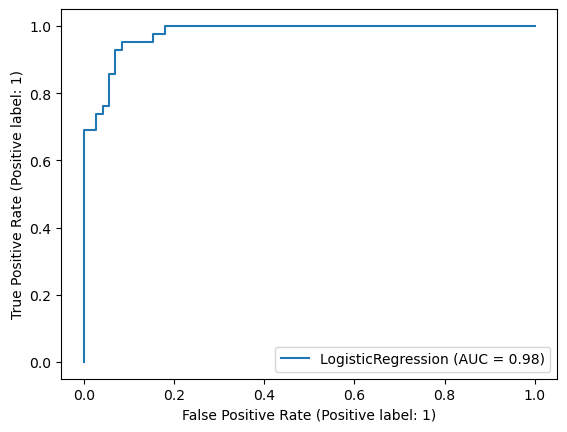

In [12]:
from sklearn import metrics
metrics.RocCurveDisplay.from_estimator(alll_model,X_test, y_test)

The radius_mean_normalized feature had the largest coefficent compared to the other features, indicating that it contributes most to predicting whether a tumor is diagnosed as malignant or benign. This observation aligns with its highest AUC ranking and greatest visual separation in the boxplots. The last model trained on all features, generating a cofficient of 4.768147684311883. This was the largest coefficient in magnitude compared to any of the models trained on a single feature. The ranking comparisons of the logistic regression results from training and testing with single features suggest a trend; the features with larger coefficents contributing more predictive influence on the model's performance. By training the last model with all the features, its able to integrate complementary information across features to make more accurate predictions than models based on a single feature.

In [13]:
rankingcoef_feature_results = feature_results.sort_values(by='coefficient', ascending = False) # Rank independent models based on coefficient values
rankingcoef_feature_results

,roc_auc_score,coefficient,intercept
radius_mean_normalized,0.936508,3.588954,-0.668448
compactness_mean_normalized,0.845238,2.016238,-0.563068
texture_mean_normalized,0.802579,1.009844,-0.624733
smoothness_mean_normalized,0.640212,0.922376,-0.566730


Question 5

In [14]:
from matplotlib import pyplot as plt
from sklearn import tree
from sklearn.metrics import confusion_matrix
from sklearn.tree import DecisionTreeClassifier

In [15]:
clf = DecisionTreeClassifier(max_depth=4).fit(X_train, y_train)
#initialize and train decision tree using same dataset as training set
#hyperparameter = your choice of depth (ie max depth 2 vs max depth 4)
results = clf.predict(X_train) #training decision tree with the training data
confusion_matrix(results, y_train) # using confusion matrix to see types of classification errors; ratio/visual performance evaluation

array([[281,  19],
       [  4, 151]])

In [16]:
from sklearn.metrics import accuracy_score #import accuracy score function 
print("accuracy:", accuracy_score(y_train, results)) 
#determine accuracy of training model trained and tested with train data only
#evaluate accuracy using predicted labels from predict(X_train) and actual training labels in y_train

accuracy: 0.9494505494505494


In [17]:
#hyperparameter = your choice of depth 

In [18]:
results = clf.predict(X_test) #generate predicted class labels
confusion_matrix(results, y_test)

array([[68,  9],
       [ 4, 33]])

In [19]:
# calculate the fpr and tpr for all thresholds of the classification
probs2 = clf.predict_proba(X_test) #testing model with test set
preds2 = probs2[:,1] #extract pred probs for positive class (malignant cases)
fpr2, tpr2, threshold2 = metrics.roc_curve(y_test, preds2) #compute false positive rate, true positive rate, and thresholds for roc curve
roc_auc2 = metrics.auc(fpr2, tpr2) #compute auc from fpr and tpr
roc_auc2 # display auc value

0.9201388888888887

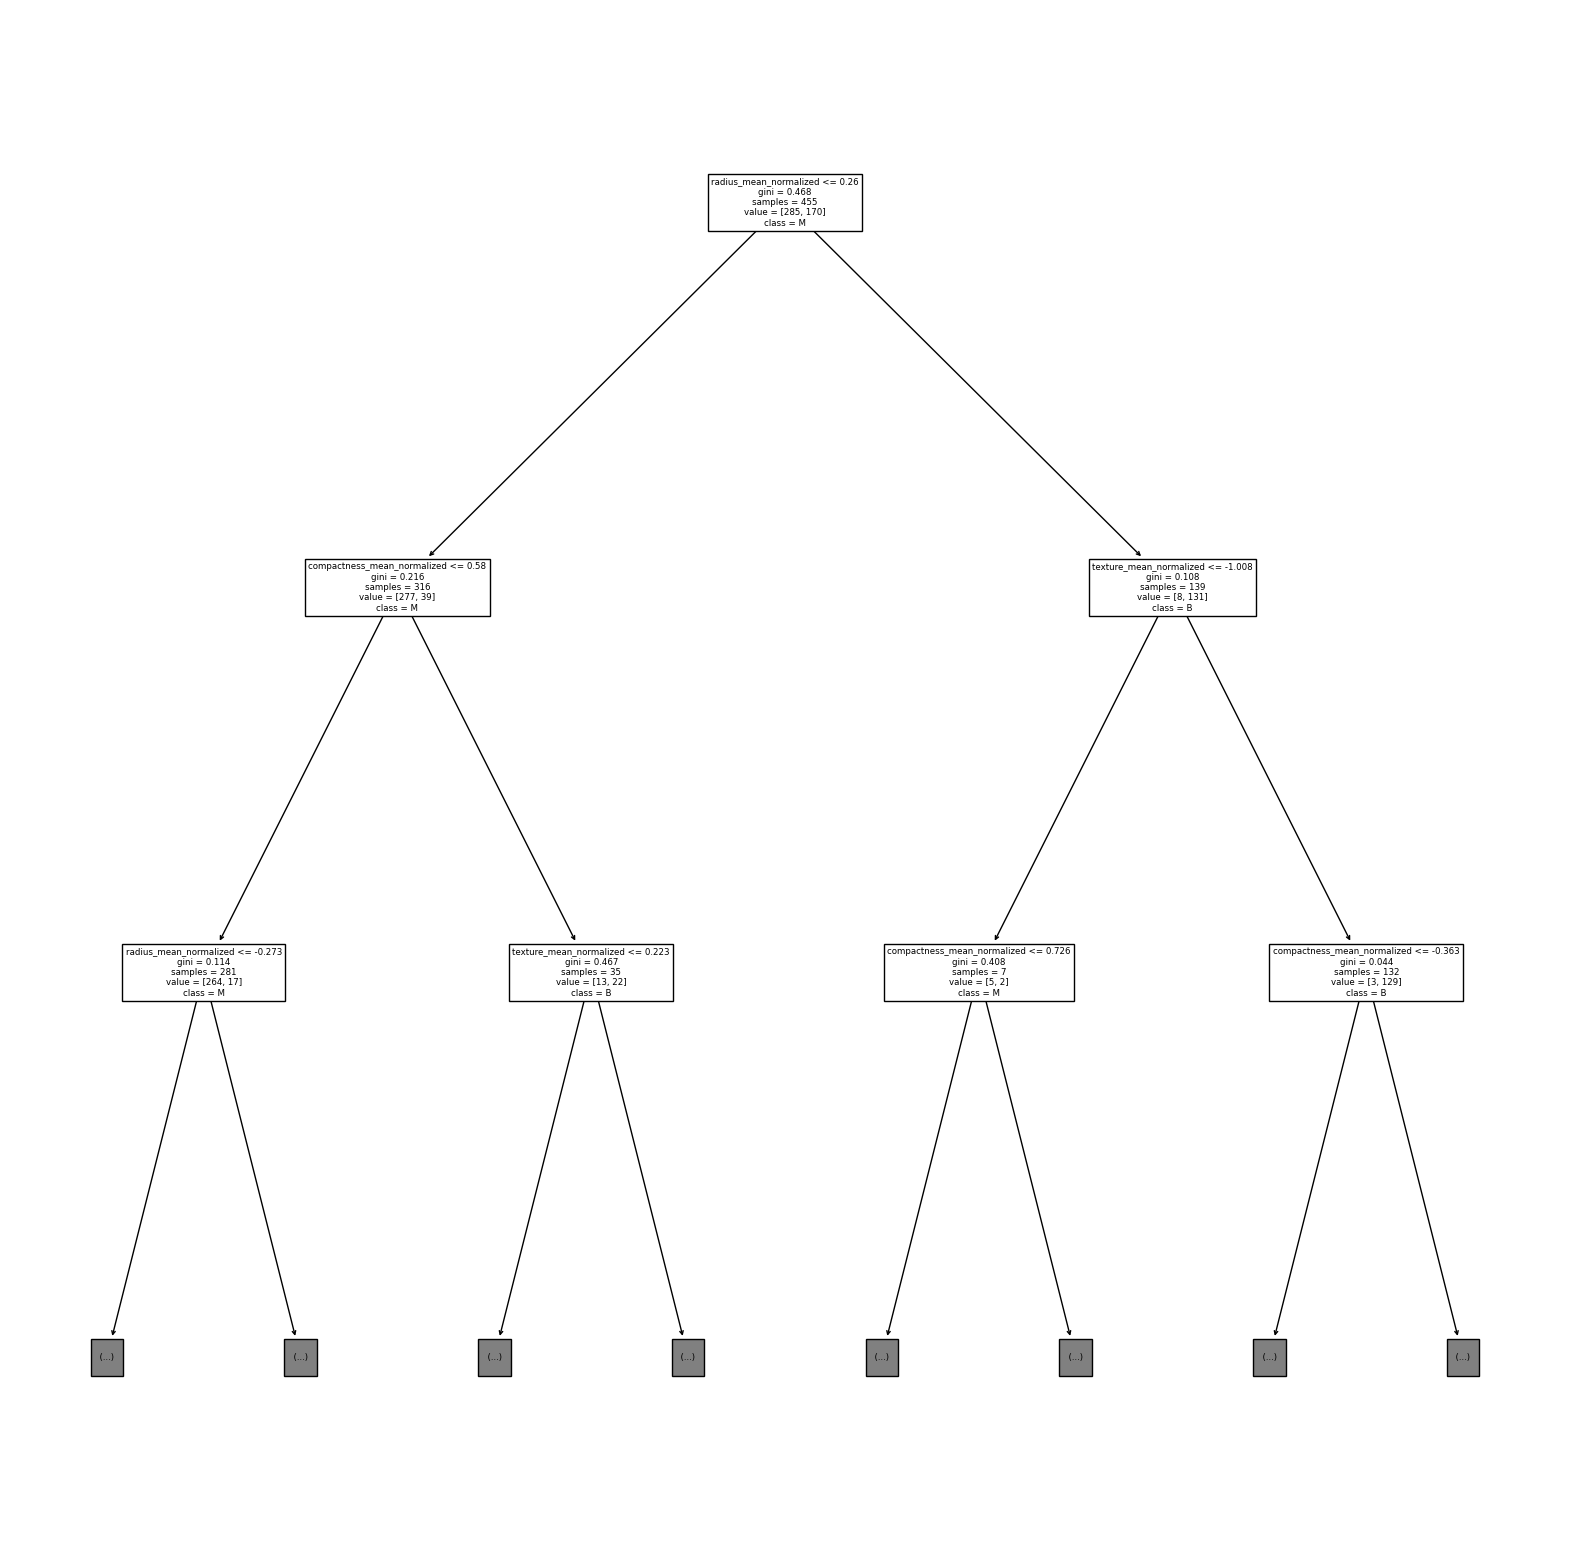

In [21]:
#Plotting the actual tree
%matplotlib inline 
#enables inline plotting within jupyter notebook, so plot shows under this cell
plt.figure(figsize=(20,20)) #set size of figure
'''plotting the decision tree with parameters - clf for trained decision tree classifier,
feature_names = names of features used in training (x) providing as a list,
class_names = class labels, ie malignant, benign;
max_depth = depth of tree, lower than hyperparameter to simplify tree for visualization'''
plot = tree.plot_tree(clf, feature_names = ["radius_mean_normalized", "texture_mean_normalized", "smoothness_mean_normalized", "compactness_mean_normalized"], class_names = ["M", "B"], max_depth = 2)
plt.show() #display

4. Which variable is the most important in predicting the outcome? How do
you know? Does this match the visualization?
The variable at the root node, the topmost split in the tree, would be the most important variable in terms of predicting the outcome;in this case, that variable would be the radius_mean_normalized. This feature provides the greatest information gain and is consistent with domain knowledge that tumor radius is a strong indicator of malignancy. This matches preliminary results in which the radius_mean feature contributed the most to the logistic regression model, based on rankings of its coefficient and AUC magnitudes.

Question 6

In [22]:
#add new row for df to add model trained using all features
feature_results.loc['all_features'] = {'roc_auc_score': all_feature_results["all_roc_auc_score"]}
feature_results.loc['tree'] = {'roc_auc_score': roc_auc2} #add another row to df for decision tree model
feature_results.index # view df's updated index to confirm both features were added



Index(['radius_mean_normalized', 'texture_mean_normalized',
       'smoothness_mean_normalized', 'compactness_mean_normalized',
       'all_features', 'tree'],
      dtype='object')

/opt/conda/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When 

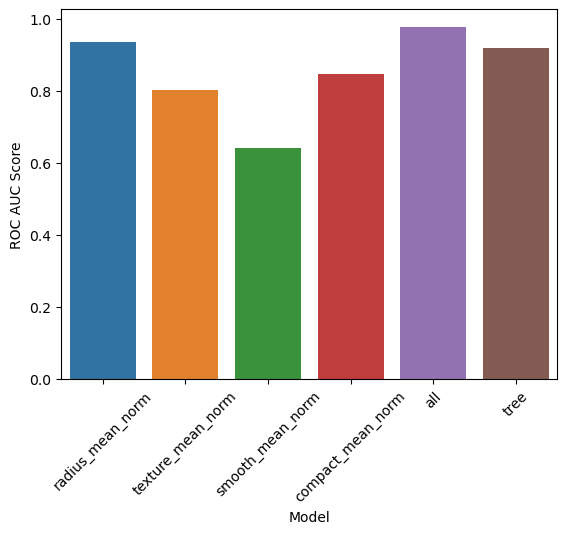

In [23]:
import seaborn as sns #import seaborn for data visualization
%matplotlib inline

#creating a barplot; hue set to give each model a unique color
plot = sns.barplot(feature_results, x = feature_results.index, y = feature_results['roc_auc_score'], hue = feature_results.index)
#rotate 45 degrees and relabel x-axis ticks
plot.set_xticklabels(labels = ["radius_mean_norm", "texture_mean_norm", "smooth_mean_norm", "compact_mean_norm", "all", "tree"], rotation=45)

#label the x and y axes
plt.xlabel('Model')
plt.ylabel('ROC AUC Score')
plt.show() #display


A bar plot comparing AUC scores between the logistic regression and decision tree models shows that the logistic regression model trained with all features outperforms all other models. 